# DATA 201 — Week 5 Assignment
## Resampling Methods with the Iris Dataset

In this assignment, we will explore **bootstrap resampling, jackknife resampling, and permutation tests** using the **Iris dataset**.

The Iris dataset contains measurements of iris flowers from three species:
- *Setosa*
- *Versicolor*
- *Virginica*

Each flower has four measurements:
- sepal length
- sepal width
- petal length
- petal width

# Author Section

- **Name:** Hunter Tzou
- **Class:** Data201 - Spring 2026

---
## Load the Dataset

In [1]:
# Load libraries and dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

iris = sns.load_dataset("iris")

### Tasks
1. Print the **number of observations** in the dataset.
2. Print the **column names**.
3. Count how many observations exist for each **species**.

In [4]:
# Task 1: Number of observations

count = len(iris)
print("Observation Count:",count)

Observation Count: 150


In [5]:
# Task 2: Column names

columns = iris.columns
print("Column Names:",columns)


Column Names: Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [13]:
# Task 3: Observations per species

species_counts = iris['species'].value_counts().rename("count").to_frame()

print(species_counts)

            count
species          
setosa         50
versicolor     50
virginica      50


---
# Part 1 — Bootstrap Resampling

We will estimate the **mean sepal length** using bootstrap resampling.

## Task 1 — Basic Statistics

Compute the following statistics for **sepal length**:
- mean
- median
- standard deviation

In [17]:
# Task 1: Basic statistics for sepal length

basic_stats = iris['sepal_length'].agg(['mean', 'median', 'std'])

basic_stats

,sepal_length
mean,5.843333
median,5.800000
std,0.828066


## Task 2 — Bootstrap the Mean

Perform **5,000 bootstrap resamples**.

Procedure:
1. Sample the dataset **with replacement**.
2. Each sample must contain **150 observations**.
3. Compute the **mean sepal length** for each resample.
4. Store the results.

Plot the **distribution of bootstrap means**.

In [25]:
# Task 2: Bootstrap resampling (5,000 iterations)

bootstrap_means = []

for i in range(5000):
    sample = iris['sepal_length'].sample(n=150, replace=True)
    bootstrap_means.append(sample.mean().round(2))



In [26]:
# Test if it is working

bs_len = len(bootstrap_means)
bs_mean = np.mean(bootstrap_means).round(2)
bs_std = np.std(bootstrap_means).round(2)
bs_first5 = bootstrap_means[:5]

print("Bootstrap Length:", bs_len)
print("Bootstrap Mean:", bs_mean)
print("Bootstrap Standard Deviation:", bs_std)
print("First 5 Bootstrap Means:", bs_first5)

Bootstrap Length: 5000
Bootstrap Mean: 5.84
Bootstrap Standard Deviation: 0.07
First 5 Bootstrap Means: [np.float64(5.89), np.float64(5.75), np.float64(5.8), np.float64(6.01), np.float64(5.91)]


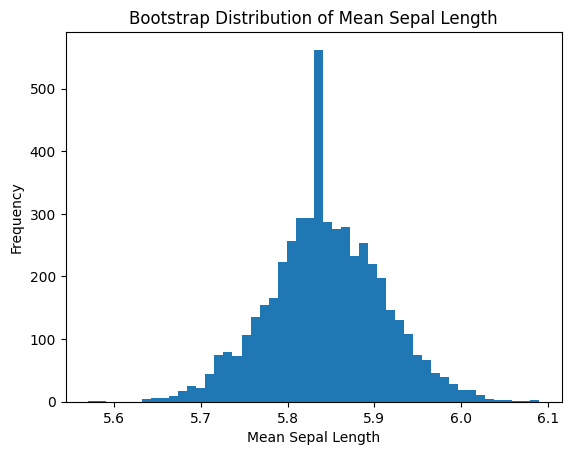

In [32]:
# Task 2: Plot distribution of bootstrap means

plt.hist(bootstrap_means, bins=50)
plt.xlabel('Mean Sepal Length')
plt.ylabel('Frequency')
plt.title('Bootstrap Distribution of Mean Sepal Length')
plt.show()


## Task 3 — Confidence Interval

Using the bootstrap results, compute the **95% confidence interval** using the percentile method:

`CI = [2.5%, 97.5%]`

Report:
- Bootstrap mean
- Lower bound
- Upper bound

In [33]:
# Task 3: 95% Confidence interval from bootstrap

lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)
boot_mean = np.mean(bootstrap_means)

print(f"Bootstrap Mean: {boot_mean:.4f}")
print(f"Lower Bound (2.5%): {lower:.4f}")
print(f"Upper Bound (97.5%): {upper:.4f}")


Bootstrap Mean: 5.8434
Lower Bound (2.5%): 5.7100
Upper Bound (97.5%): 5.9800


### ✏️ Question
**Why is it mathematically necessary to sample *with replacement* in bootstrap resampling?**

RESPONSE:

- It is necessary because without resampling, the dataset would just be iterated several times and then the resulting statistics would be exactly the same. With resampling, we can simulate randomness just like we see in nature.

---
# Part 2 — Jackknife Resampling

## Task 4 — Jackknife the Mean

Create jackknife samples by removing **one observation at a time**.

Steps:
1. For each observation i, remove it from the dataset.
2. Compute the mean of the remaining observations.
3. Store the result.

Plot the **distribution of jackknife means**.

In [34]:
# Task 4: Jackknife resampling

jackknife_means = []

for i in range(len(iris)):
    sample = iris['sepal_length'].drop(index=i)
    jackknife_means.append(sample.mean())

In [36]:
jk_len = len(jackknife_means)
jk_mean = np.mean(jackknife_means).round(2)

print("Jackknife Length:", jk_len)
print("Jackknife Mean:", jk_mean)

Jackknife Length: 150
Jackknife Mean: 5.84


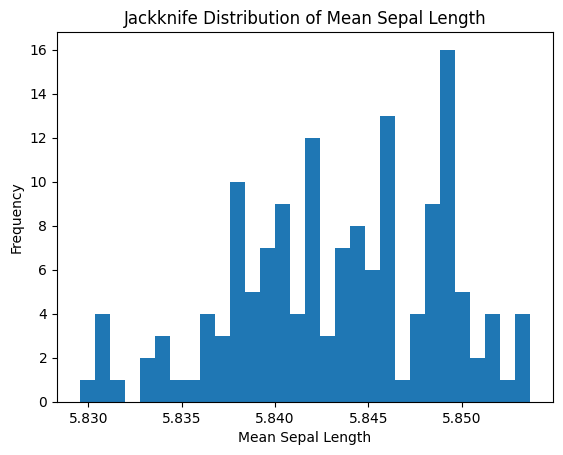

In [40]:
# Task 4: Plot distribution of jackknife means

plt.hist(jackknife_means, bins=30)
plt.xlabel('Mean Sepal Length')
plt.ylabel('Frequency')
plt.title('Jackknife Distribution of Mean Sepal Length')
plt.show()


### ✏️ Question
**If the dataset contains n observations, exactly how many jackknife samples are created?**

RESPONSE:

There are going to be n observations since it will remove every observation at least once. It is deterministic unlike bootstrap which is random.

---
# Part 3 — Permutation Test

We will test whether **sepal length differs significantly between two species**.

For this task, use:
- **Versicolor**
- **Virginica**

## Task 5 — Observed Statistic

Compute the observed difference in means:

`difference = mean(Versicolor) − mean(Virginica)`

In [52]:
# Task 5: Compute observed difference in means

Versi_mean = iris.loc[iris['species'] == 'versicolor', 'sepal_length'].mean().round(2)
Virgi_mean = iris.loc[iris['species'] == 'virginica', 'sepal_length'].mean().round(2)

obs_difference = Versi_mean - Virgi_mean

print("Observed Difference in Means:", (obs_difference).round(2))


Observed Difference in Means: -0.65


## Task 6 — Permutation Simulation

Run **1,000 permutations**.

Procedure:
1. Combine the two species into one dataset.
2. **Shuffle (permute) the labels**.
3. Split the data back into two groups of the original sizes.
4. Compute the difference in means.
5. Store the result.

Plot the **permutation distribution**.

In [43]:
# Task 6: Permutation simulation (1,000 permutations)

versicolor = iris[iris['species'] == 'versicolor']['sepal_length']
virginica = iris[iris['species'] == 'virginica']['sepal_length']

combined = pd.concat([versicolor, virginica])

permutation_diffs = []

for i in range(1000):
    shuffled = combined.sample(frac=1).reset_index(drop=True)
    group1 = shuffled[:len(versicolor)]
    group2 = shuffled[len(versicolor):]
    permutation_diffs.append(group1.mean() - group2.mean())


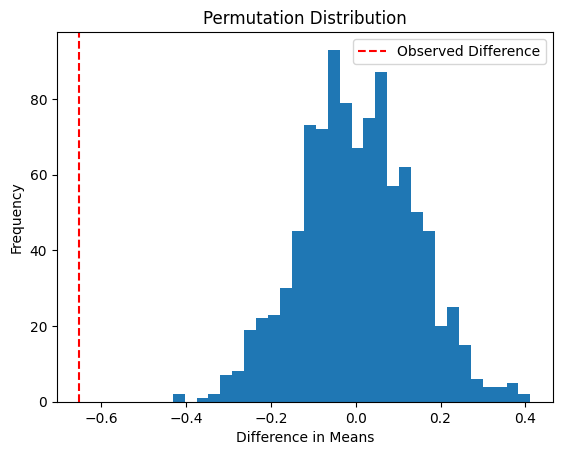

In [45]:
# Task 6: Plot permutation distribution

plt.hist(permutation_diffs, bins=30)
plt.axvline(obs_difference, color='red', linestyle='dashed', label='Observed Difference')
plt.xlabel('Difference in Means')
plt.ylabel('Frequency')
plt.title('Permutation Distribution')
plt.legend()
plt.show()


The observed difference lands way out in the tail of that distribution, it's unlikely to have happened by chance — so we reject the null hypothesis.

## Task 7 — p-value

Compute the p-value:

`p = (number of simulated differences ≥ observed difference) / (total simulations)`

Interpret the result at α = 0.05.

In [53]:
# Task 7: Compute p-value

p_value = np.sum(np.abs(permutation_diffs) >= np.abs(obs_difference)) / len(permutation_diffs)

print(f"Observed Difference: {obs_difference:.4f}")
print(f"P-value: {p_value:.4f}")

Observed Difference: -0.6500
P-value: 0.0000


### ✏️ Questions

**1. What is the null hypothesis (H0) in this specific test?**

RESPONSE:

There is no difference in mean sepal length between Versicolor and Virginica.

---

**2. What does the permutation distribution represent in terms of random chance?**

RESPONSE:

The fact that the observed difference lands way outside the permutation distribution is strong visual evidence against that — it suggests the difference we see in the real data is far too large to be explained by random chance alone.


---

**3. Based on your p-value, do you reject or fail to reject the null hypothesis?**

RESPONSE:

We reject the null hypothesis.